In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
import matplotlib.pyplot as plt
import itertools
import numpy as np
import holidays



In [20]:
# Cargamos el dataset, asumiendo que la primera columna es la marca de tiempo
df = pd.read_csv("C:/Users/alexa/OneDrive/Documentos/Curso5/Proyectos4/casa_7_clima.csv", parse_dates=True)
df = df.drop(columns=['fecha'])

In [21]:
# Renombramos target a 'y' y creamos 'ds'
df = df.rename(columns={'timestamp':'ds', 'consumo_kWh':'y'})
df = df.drop(columns=['altitud','tmed','tmin','tmax'])

In [ ]:
# 3. Calcula de nuevo TODOS los regresores 
df['lag_1']   = df['y'].shift(1)
df['lag_24']  = df['y'].shift(24)
df['lag_168'] = df['y'].shift(168)
for w in [3,6,24]:
    df[f'rollmean_{w}'] = df['y'].shift(1).rolling(w).mean()
df['week_avg']   = df['y'].shift(1).rolling(168).mean()
df['trend_diff'] = df['y'].shift(1) - df['week_avg']

time = pd.to_datetime(df['ds'])

df['hour']       = time.dt.hour
df['dayofweek']  = time.dt.weekday
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

In [23]:
# 4. Elimina NaNs y queda sólo ds, y + regresores
final_regs = [
    'lag_1','lag_24','lag_168',
    'rollmean_3','rollmean_6','rollmean_24',
    'trend_diff',
    'temperatura','velmedia','sol','presMax','prec_valor'
]
keep_cols = ['ds','y'] + final_regs + ['hour','dayofweek','is_weekend']
df_cv_input = df[keep_cols].dropna().reset_index(drop=True)

In [ ]:
# Parámetros 
best_params = {
    'changepoint_prior_scale': 0.1,
    'seasonality_prior_scale': 10.0,
    'seasonality_mode': 'additive'
}

In [25]:
# ==============================
# 4. Holidays centrados en Barcelona (Cataluña)
# ==============================
# Generamos el calendario de festivos de España, provincia CT (Cataluña)
date = pd.to_datetime(df['ds'])
years = range(date.dt.year.min(), date.dt.year.max()+1)
spain_ct = holidays.Spain(prov='CT', years=years)
holiday_df = pd.DataFrame([
    {'ds': pd.to_datetime(day), 'holiday': name}
    for day, name in spain_ct.items()
])

In [26]:
# 7. Construcción y ajuste del modelo Prophet
m_cv = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    holidays=holiday_df,
    **best_params
)
# añade TODOS los regresores
for r in final_regs + ['hour','dayofweek','is_weekend']:
    m_cv.add_regressor(r)

In [ ]:
# entrena con todo el dataset preparado
m_cv.fit(df_cv_input)

# Cross-validation
df_cv = cross_validation(
    m_cv,
    initial='365.25 days',   
    period='10 days',       
    horizon='12 hours',     
    parallel='processes'
)


19:47:55 - cmdstanpy - INFO - Chain [1] start processing
19:48:00 - cmdstanpy - INFO - Chain [1] done processing


          horizon       mse      rmse       mae      mdape     smape  coverage
0 0 days 02:00:00  0.430878  0.656413  0.247353  21.808214  1.569705  0.903632
1 0 days 03:00:00  0.228356  0.477866  0.181776  41.902613  1.699978  0.941162
2 0 days 04:00:00  0.181562  0.426101  0.161957  12.758390  1.743741  0.949153
3 0 days 05:00:00  0.168636  0.410654  0.150707  15.433306  1.568174  0.934867
4 0 days 06:00:00  0.101625  0.318786  0.211916  24.069997  1.330203  0.960775
horizon     0 days 07:00:00
mse                 0.17942
mae                0.230764
rmse                0.41373
mdape             10.569222
coverage            0.92199
dtype: object


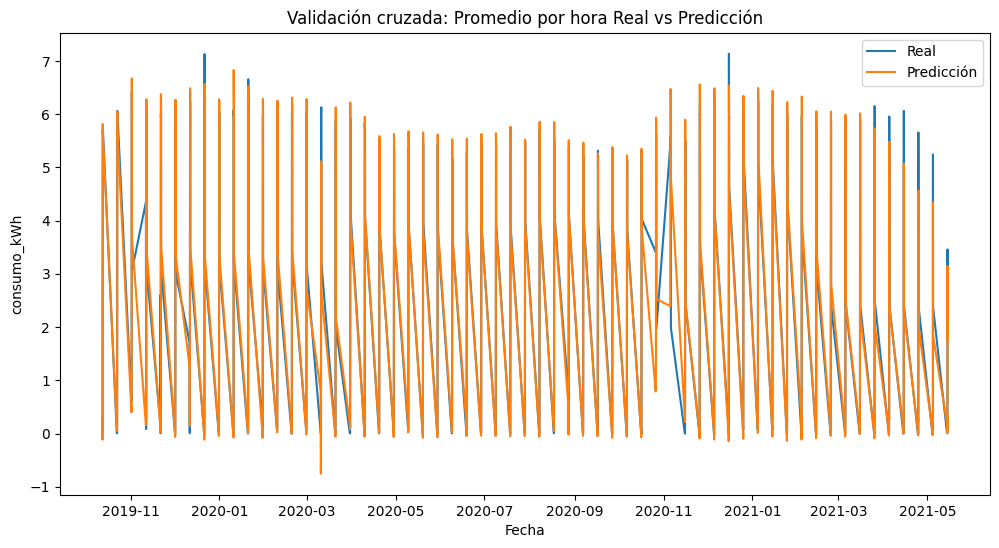

In [ ]:
# Métricas de rendimiento
df_p = performance_metrics(df_cv)

print(df_p.head())

df_p_mean = df_p.mean()
df_p_mean = df_p_mean.rename(index={0:'mean'})
df_p_mean = df_p_mean[['horizon','mse','mae','rmse','mdape','coverage']]
print(df_p_mean)

import matplotlib.pyplot as plt

df_plot = df_cv.groupby('ds')[['y','yhat']].mean().reset_index()

plt.figure(figsize=(12,6))
plt.plot(df_plot['ds'], df_plot['y'],   label='Real')
plt.plot(df_plot['ds'], df_plot['yhat'], label='Predicción')
plt.xlabel('Fecha')
plt.ylabel('consumo_kWh')
plt.title('Validación cruzada: Promedio por hora Real vs Predicción')
plt.legend()
plt.show()



In [ ]:
# ==============================
# 5. Grid search y CV optimizando horizonte 1 h
# ==============================
# Hiperparámetros a tunear
param_grid = {
    'changepoint_prior_scale': [0.01, 0.1, 0.5],
    'seasonality_prior_scale': [1.0, 10.0, 20.0],
    'seasonality_mode':        ['additive','multiplicative']
}
all_params = [dict(zip(param_grid.keys(), vals))
              for vals in itertools.product(*param_grid.values())]

# Almacenaremos resultados
results = []

for set_name, regs in regressor_sets.items():
    best_rmse = np.inf
    best_params = None
    
    for params in all_params:
        m = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=True,
            daily_seasonality=True,
            holidays=holiday_df,
            **params
        )
        
        for r in regs:
            m.add_regressor(r)
        
        m.fit(df_model[['ds','y'] + regs])
        
        df_cv = cross_validation(
            m,
            initial='365 days',
            period='7 days',
            horizon='1 hours',
            parallel='processes'
        )
        perf = performance_metrics(df_cv)
        rmse_1h = perf[perf.horizon=='1 hours']['rmse'].values[0]
        
        if rmse_1h < best_rmse:
            best_rmse = rmse_1h
            best_params = params
    
    results.append({
        'regressor_set': set_name,
        'best_params': best_params,
        'rmse_1h': best_rmse
    })

for r in results:
    print(f"Set: {r['regressor_set']}, RMSE @1h: {r['rmse_1h']:.4f}, params: {r['best_params']}")

best = min(results, key=lambda x: x['rmse_1h'])
print("\nMejor conjunto:", best['regressor_set'])



11:44:10 - cmdstanpy - INFO - Chain [1] start processing
11:44:26 - cmdstanpy - INFO - Chain [1] done processing
11:44:26 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
11:48:06 - cmdstanpy - INFO - Chain [1] start processing
11:48:06 - cmdstanpy - INFO - Chain [1] start processing
11:48:16 - cmdstanpy - INFO - Chain [1] done processing
11:48:16 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
11:50:41 - cmdstanpy - INFO - Chain [1] start processing
11:50:41 - cmdstanpy - INFO - Chain [1] start processing
11:50:56 - cmdstanpy - INFO - Chain [1] done processing
11:50:56 - cmdstanp

Set: base, RMSE @1h: 2.2433, params: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 20.0, 'seasonality_mode': 'additive'}
Set: with_meteo, RMSE @1h: 2.1975, params: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'additive'}

Mejor conjunto: with_meteo


In [ ]:
# ==============================
# 6. Ajuste final y pronóstico
# ==============================
# Preparamos el modelo con el mejor set y parámetros
final_regs = regressor_sets[best['regressor_set']]
m_final = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    holidays=holiday_df,
    **best['best_params']
)
for r in final_regs:
    m_final.add_regressor(r)

# Entrenamos con todos los datos
m_final.fit(df_model[['ds','y'] + final_regs])

18:11:49 - cmdstanpy - INFO - Chain [1] start processing
18:12:33 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
df_model[['ds','y'] + final_regs]

,ds,y,lag_1,lag_24,lag_168,rollmean_3,rollmean_6,rollmean_24,trend_diff,temperatura,velmedia,sol,presMax,prec_valor
0,2017-12-22 12:00:00,73.0,69.0,72.0,66.0,67.000000,55.500000,55.041667,18.089286,12.75,9.4,5.1,983.6,0.00
1,2017-12-22 13:00:00,70.0,73.0,72.0,71.0,70.000000,61.333333,55.083333,15.047619,13.18,9.4,5.1,983.6,0.00
2,2017-12-22 14:00:00,71.0,70.0,75.0,76.0,70.666667,65.500000,55.000000,16.053571,13.50,9.4,5.1,983.6,0.00
3,2017-12-22 15:00:00,75.0,71.0,78.0,78.0,71.333333,69.166667,54.833333,20.083333,13.68,9.4,5.1,983.6,0.00
4,2017-12-22 16:00:00,70.0,75.0,72.0,67.0,72.000000,71.000000,54.708333,15.101190,13.68,9.4,5.1,983.6,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19088,2020-02-25 20:00:00,73.0,67.0,67.0,73.0,52.666667,50.666667,47.958333,31.726190,13.20,4.2,3.6,970.4,0.05
19089,2020-02-25 21:00:00,70.0,73.0,69.0,68.0,62.666667,55.000000,48.208333,28.726190,13.29,4.2,3.6,970.4,0.05
19090,2020-02-25 22:00:00,54.0,70.0,50.0,49.0,70.000000,58.666667,48.250000,12.714286,13.19,4.2,3.6,970.4,0.05
19091,2020-02-25 23:00:00,31.0,54.0,34.0,32.0,65.666667,59.166667,48.416667,-10.315476,13.44,4.2,3.6,970.4,0.05


In [ ]:
last = df_model.iloc[-1]
next_ds = pd.to_datetime(last['ds']) + pd.Timedelta(hours=1)
df_pred = pd.DataFrame({'ds': [next_ds]})

for r in final_regs:
    if r.startswith('lag_'):
        lag = int(r.split('_')[1])
        df_pred[r] = df_model['y'].iloc[-lag]
    elif r.startswith('rollmean_'):
        window = int(r.split('_')[1])
        df_pred[r] = df_model['y'].iloc[-window:].mean()
    elif r == 'trend_diff':
        week_avg = df_model['y'].iloc[-168:].mean()
        last_y   = df_model['y'].iloc[-1]
        df_pred[r] = last_y - week_avg
    else:
        df_pred[r] = last[r]

forecast = m_final.predict(df_pred)
